# Análisis de la estacionalidad de la demanda turística
## Pregunta de negocio

¿En qué meses se concentra la demanda turística en los destinos donde opera StaySpain?

Fuente:
Encuesta de Ocupación Hotelera (EOH) - INE

Periodo:
2023-2025

## Objetivo

Analizar la distribución mensual de las pernoctaciones en los destinos donde opera
StaySpain para identificar la existencia de patrones estacionales.

La EOH utiliza las pernoctaciones como principal indicador de demanda turística, este análisis permitirá identificar los meses de mayor actividad
y apoyar decisiones relacionadas con precios, disponibilidad y campañas de marketing.

In [6]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
# Parámetros de ejecución
DATASET_FILES = {
    "2074": "EOH_2074_raw_20_07_2026.csv",   # Comunidades Autónomas
    "2078": "EOH_2078_raw_20_07_2026.csv",   # Puntos turísticos
    "2039": "EOH_2039_raw_20_07_2026.csv",   # Zonas turísticas (Mallorca y Menorca)
}

FECHA_EDA = pd.Timestamp.today().strftime("%d/%m/%Y")

# Periodo de análisis
PERIODO_INICIO = pd.Timestamp("2023-01-01")
PERIODO_FIN = pd.Timestamp("2025-12-01")

def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """Busca la carpeta raíz del proyecto desde el directorio actual."""
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' "
        f"subiendo desde {actual}"
    )

raiz_proyecto = encontrar_raiz_proyecto("Equip_34")

# Carga de los datasets
dfs_raw = {}

for clave, nombre_archivo in DATASET_FILES.items():

    ruta_csv = raiz_proyecto / "Data" / nombre_archivo

    if not ruta_csv.exists():
        raise FileNotFoundError(f"No se encontró el dataset: {nombre_archivo}")
    dfs_raw[clave] = pd.read_csv(
        ruta_csv,
        sep=";",
        encoding="utf-8-sig"
    )
print(f"Fecha de ejecución: {FECHA_EDA}")

for clave, df in dfs_raw.items():
    print(
        f"Tabla {clave}: "
        f"{df.shape[0]:>7,d} filas x "
        f"{df.shape[1]} columnas -> "
        f"{list(df.columns)}"
    )

Fecha de ejecución: 22/07/2026
Tabla 2074: 138,180 filas x 8 columnas -> ['Totales Territoriales', 'Comunidades y Ciudades Autónomas', 'Provincias', 'Viajeros y pernoctaciones', 'Residencia: Nivel 1', 'Residencia: Nivel 2', 'Periodo', 'Total']
Tabla 2078: 141,864 filas x 5 columnas -> ['Puntos turísticos', 'Viajeros y pernoctaciones', 'Residencia', 'Periodo', 'Total']
Tabla 2039:  63,168 filas x 5 columnas -> ['Zonas Turísticas', 'Viajeros y pernoctaciones', 'Residencia', 'Periodo', 'Total']


In [ ]:
def parsear_total(serie):

    texto = serie.astype("string").str.strip()
    texto = texto.replace({
        ".":pd.NA,
        "..":pd.NA
    })
    texto = texto.str.replace(".","",regex=False)
    texto = texto.str.replace(",",".",regex=False)
    return pd.to_numeric(
        texto,
        errors="coerce"
    )

def parsear_periodo(serie):
    return pd.to_datetime(
        serie.str.replace("M","-",regex=False)+"-01",
        format="%Y-%m-%d"
    )

dfs = {}

for clave,df in dfs_raw.items():
    copia = df.copy()
    copia["Total_num"] = parsear_total(copia["Total"])
    copia["Fecha"] = parsear_periodo(copia["Periodo"])
    dfs[clave] = copia
df_2039 = dfs["2039"]
df_2074 = dfs["2074"]
df_2078 = dfs["2078"]

In [ ]:
MAPEO_CCAA = {
    "Barcelona":"09 Cataluña",
    "Girona":"09 Cataluña",
    "Madrid":"13 Madrid, Comunidad de",
    "Valencia":"10 Comunitat Valenciana",
    "Málaga":"01 Andalucía",
    "Sevilla":"01 Andalucía",
    "Mallorca":"04 Balears, Illes",
    "Menorca":"04 Balears, Illes"
}
MAPEO_PUNTO = {
    "Barcelona":"08019 Barcelona",
    "Madrid":"28079 Madrid",
    "Girona":"17079 Girona",
    "Valencia":"46250 València",
    "Málaga":"29067 Málaga",
    "Sevilla":"41091 Sevilla"
}
MAPEO_ZONA = {
    "Mallorca":"Baleares (Illes): Isla De Mallorca",
    "Menorca":"Baleares (Illes): Isla De Menorca"
}


In [ ]:
ccaa_interes = sorted(set(MAPEO_CCAA.values()))
serie_ccaa = (
    df_2074

    [   (df_2074["Provincias"].isna())
        &
        (df_2074["Comunidades y Ciudades Autónomas"].isin(ccaa_interes))
        &
        (df_2074["Viajeros y pernoctaciones"]=="Pernoctaciones")
        &
        (df_2074["Residencia: Nivel 2"].isna())
        &
        (df_2074["Fecha"].between(PERIODO_INICIO,PERIODO_FIN))
    ]

).copy()

In [ ]:
serie_ccaa["Comunidad"] = (
    serie_ccaa["Comunidades y Ciudades Autónomas"]
    .str.split(",")
    .str[0]
    .str.split(":")
    .str[0]

)

serie_ccaa["Mes"] = serie_ccaa["Fecha"].dt.month

serie_ccaa.head()

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Viajeros y pernoctaciones,Residencia: Nivel 1,Residencia: Nivel 2,Periodo,Total,Total_num,Fecha,Comunidad,Mes
2966,Total Nacional,01 Andalucía,NaN,Pernoctaciones,Total,NaN,2025M12,2.693.046,2693046,2025-12-01,01 Andalucía,12
2967,Total Nacional,01 Andalucía,NaN,Pernoctaciones,Total,NaN,2025M11,3.145.703,3145703,2025-11-01,01 Andalucía,11
2968,Total Nacional,01 Andalucía,NaN,Pernoctaciones,Total,NaN,2025M10,5.250.858,5250858,2025-10-01,01 Andalucía,10
2969,Total Nacional,01 Andalucía,NaN,Pernoctaciones,Total,NaN,2025M09,6.176.273,6176273,2025-09-01,01 Andalucía,9
2970,Total Nacional,01 Andalucía,NaN,Pernoctaciones,Total,NaN,2025M08,7.586.225,7586225,2025-08-01,01 Andalucía,8


## 7. Evolución mensual de las pernoctaciones

En primer lugar se analiza la evolución mensual de las pernoctaciones en las
comunidades autónomas donde opera StaySpain.

Las pernoctaciones representan el número de noches que los viajeros permanecen
alojados y constituyen el indicador más adecuado para estudiar la estacionalidad
de la demanda turística.

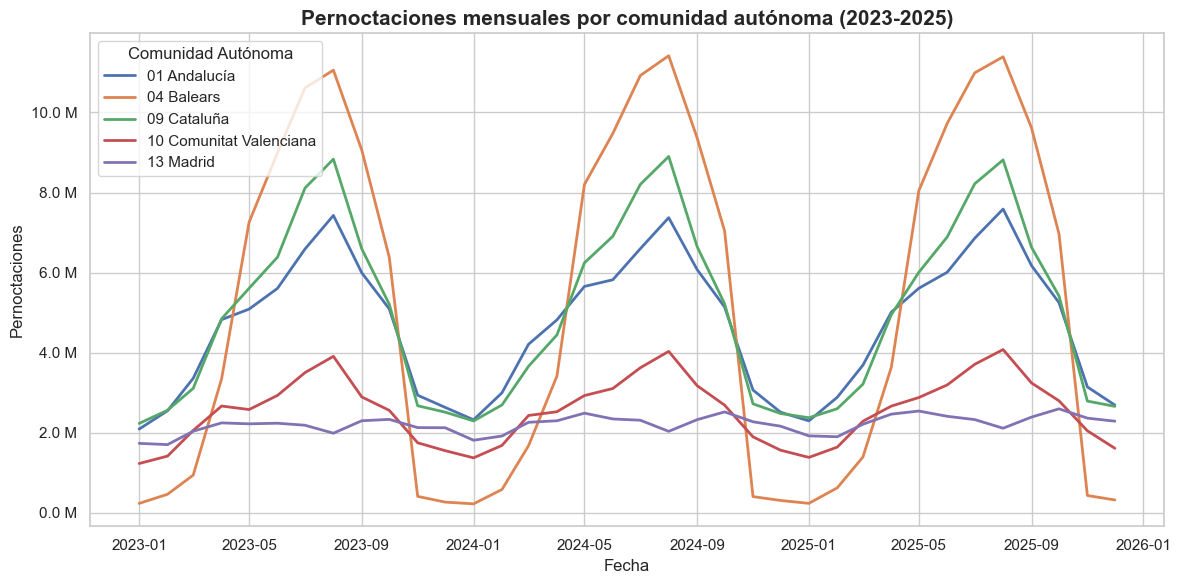

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
for comunidad, grupo in serie_ccaa.groupby("Comunidad"):
    grupo = grupo.sort_values("Fecha")
    ax.plot(
        grupo["Fecha"],
        grupo["Total_num"],
        linewidth=2,
        label=comunidad
    )
ax.set_title(
    "Pernoctaciones mensuales por comunidad autónoma (2023-2025)",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Pernoctaciones")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_: f"{x/1e6:.1f} M"
    )
)

plt.legend(title="Comunidad Autónoma")

plt.tight_layout()

plt.show()

### Interpretación

El gráfico permite observar la evolución temporal de las pernoctaciones en las
cinco comunidades autónomas donde StaySpain desarrolla su actividad.

Se aprecia un comportamiento claramente estacional en la mayoría de destinos,
aunque con intensidades diferentes según la comunidad autónoma.

## 8. Patrón estacional medio (2023-2025)

Para identificar la estacionalidad típica se calcula la media de
pernoctaciones de cada mes durante el periodo 2023-2025.

De esta forma se elimina el efecto de un año concreto y se obtiene
el comportamiento estacional representativo de cada comunidad autónoma.

In [17]:
estacionalidad_media = (
    serie_ccaa
    .groupby(
        ["Comunidad","Mes"]
    )["Total_num"]
    .mean()
    .reset_index()
)

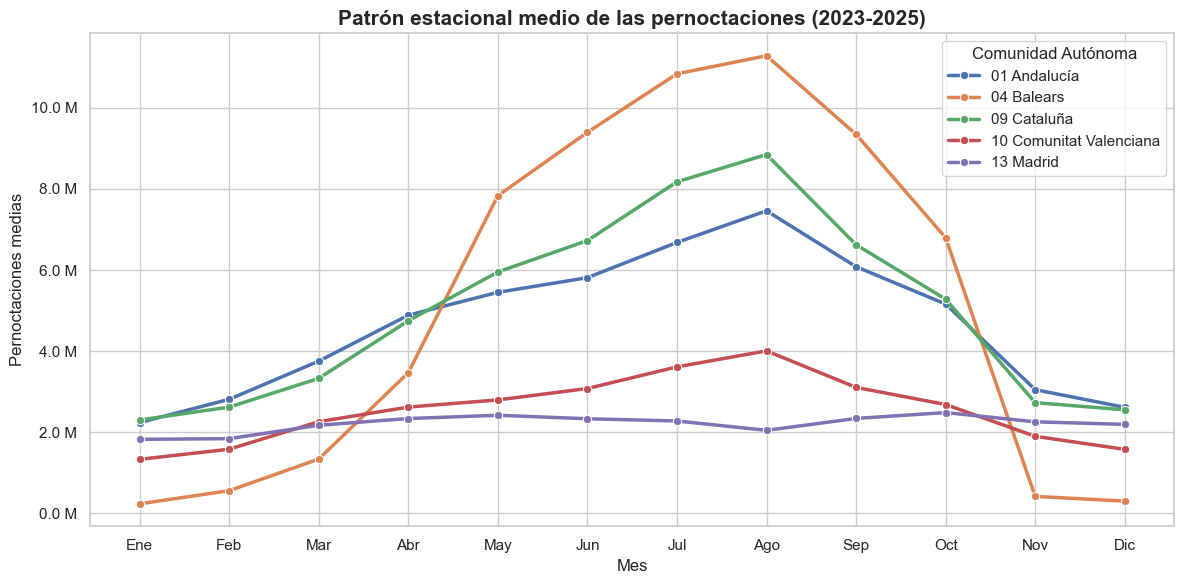

In [18]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=estacionalidad_media,
    x="Mes",
    y="Total_num",
    hue="Comunidad",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    "Patrón estacional medio de las pernoctaciones (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones medias")
ax.set_xticks(range(1,13))
ax.set_xticklabels([
    "Ene","Feb","Mar","Abr","May","Jun",
    "Jul","Ago","Sep","Oct","Nov","Dic"
])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_:f"{x/1e6:.1f} M"
    )
)
plt.legend(title="Comunidad Autónoma")
plt.tight_layout()
plt.show()

### Interpretación

Al promediar los tres años se observa con mayor claridad el patrón
estacional característico de cada comunidad autónoma.

Illes Balears presenta la mayor concentración de demanda durante los
meses de verano.

Andalucía, Cataluña y Comunitat Valenciana también muestran un fuerte
incremento de las pernoctaciones entre junio y septiembre.

Madrid presenta una evolución más estable a lo largo del año,
con un comportamiento diferente al resto de destinos turísticos.

## 9. Intensidad de la estacionalidad

Se representa la intensidad media de las pernoctaciones mediante un mapa
de calor para facilitar la identificación visual de los meses con mayor
demanda en cada comunidad autónoma.

In [33]:
heatmap = (
    serie_ccaa
    .groupby(
        ["Comunidad","Mes"]
    )["Total_num"]
    .mean()
    .unstack()
)
heatmap = heatmap.astype("float")

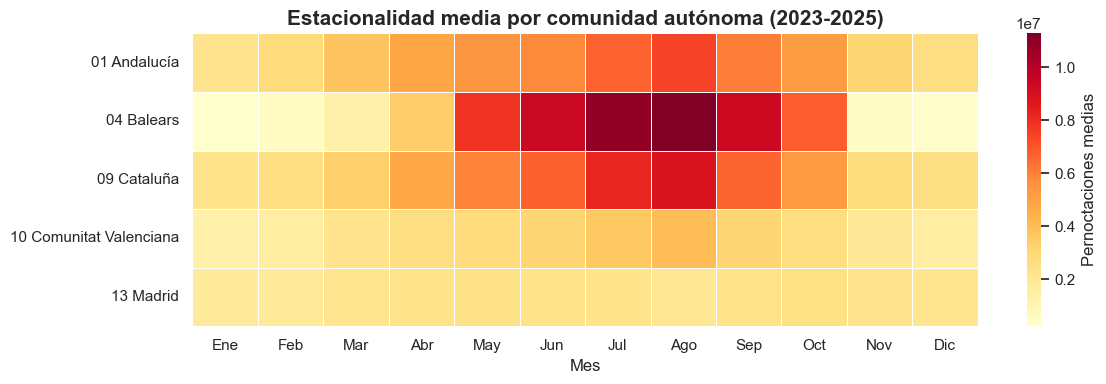

In [34]:
plt.figure(figsize=(12,4))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    linewidths=.5,

    cbar_kws={

        "label":"Pernoctaciones medias"

    }

)

plt.title(

    "Estacionalidad media por comunidad autónoma (2023-2025)",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Mes")

plt.ylabel("")

plt.xticks(

    np.arange(12)+0.5,

    [

        "Ene","Feb","Mar","Abr","May","Jun",

        "Jul","Ago","Sep","Oct","Nov","Dic"

    ]

)

plt.tight_layout()

plt.show()

### Interpretación

El mapa de calor confirma la existencia de una marcada estacionalidad.

Illes Balears concentra el mayor volumen de pernoctaciones durante los
meses de julio y agosto.

Andalucía, Cataluña y Comunitat Valenciana presentan un patrón muy
similar, aunque menos intenso.

Madrid mantiene una distribución más homogénea durante todo el año,
lo que indica una menor dependencia del turismo estacional.

## 10. Identificación del mes de mayor demanda

Con el objetivo de facilitar la interpretación para negocio, se identifica el
mes con el mayor número medio de pernoctaciones en cada comunidad autónoma.

Este indicador permite conocer cuándo se produce el pico de demanda turística
en los principales mercados donde opera StaySpain.

In [ ]:
mes_pico = (

    estacionalidad_media .loc[

        estacionalidad_media
        .groupby("Comunidad")["Total_num"
        .idxmax()

    ].sort_values("Total_num", ascending=False))

mes_pico

,Comunidad,Mes,Total_num
19,04 Balears,8,11286076.0
31,09 Cataluña,8,8849232.0
7,01 Andalucía,8,7461795.666667
43,10 Comunitat Valenciana,8,4007302.0
57,13 Madrid,10,2485764.333333


In [36]:
tabla_resumen = (

    mes_pico

    [["Comunidad","Mes","Total_num"]]

    .rename(columns={

        "Mes":"Mes pico",

        "Total_num":"Pernoctaciones medias"

    })

)

tabla_resumen

,Comunidad,Mes pico,Pernoctaciones medias
19,04 Balears,8,11286076.0
31,09 Cataluña,8,8849232.0
7,01 Andalucía,8,7461795.666667
43,10 Comunitat Valenciana,8,4007302.0
57,13 Madrid,10,2485764.333333


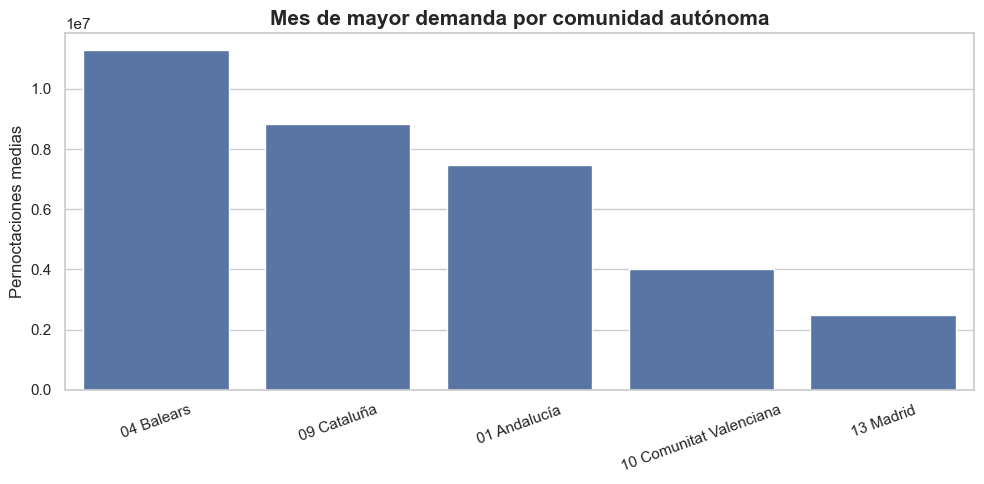

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=tabla_resumen,

    x="Comunidad",

    y="Pernoctaciones medias"

)

plt.title(

    "Mes de mayor demanda por comunidad autónoma",

    fontsize=15,

    fontweight="bold"

)

plt.ylabel("Pernoctaciones medias")

plt.xlabel("")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

### Interpretación

La mayoría de comunidades presentan su máximo volumen de pernoctaciones durante
los meses estivales.

Illes Balears registra el mayor pico de demanda, seguida de Cataluña y
Andalucía, mientras que Madrid muestra una distribución más equilibrada a lo
largo del año.

## 11. Comparación entre ciudades

In [ ]:
serie_ciudades = (

    df_2078
    [
        (df_2078["Puntos turísticos"].isin(MAPEO_PUNTO.values()))
        &
        (df_2078["Viajeros y pernoctaciones"]=="Pernoctaciones")
        &
        (df_2078["Fecha"].between(PERIODO_INICIO,PERIODO_FIN))
    ]
).copy()

In [ ]:
serie_ciudades["Ciudad"] = (
    serie_ciudades["Puntos turísticos"]
    .replace({
        v:k
        for k,v in MAPEO_PUNTO.items()
    })
)

serie_ciudades["Mes"] = serie_ciudades["Fecha"].dt.month

In [42]:
ciudades_media = (

    serie_ciudades.groupby(
        ["Ciudad","Mes"]
    )["Total_num"].mean().reset_index()
)